In [8]:
from langchain_openrouter import ChatOpenRouter
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters  import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, AnyMessage, AIMessage
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

In [3]:
load_dotenv()

True

In [4]:
llm = ChatOpenRouter(
    model="openai/gpt-oss-20b:free",
    temperature=0
)

In [5]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [7]:
def chat_node(state: ChatState):
    decision=interrupt({
        "types":"approval",
        "reason":"Model is about to answer a user question.",
        "question":state["messages"][-1].content,
        "instruction":"Approve this question? yes/no"
    })

    if decision["approved"]=='no':
        return {"messages":[AIMessage(content="Not Approved.")]}
    
    else:
        response=llm.invoke(state["messages"])
        return {"messages":[response]}

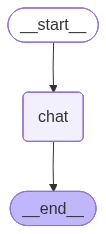

In [24]:
graph = StateGraph(ChatState)

graph.add_node('chat', chat_node)

graph.add_edge(START, 'chat')
graph.add_edge('chat', END)

checkpointer=MemorySaver()

app = graph.compile(checkpointer=checkpointer)
app

In [25]:
config={"configurable":{"thread_id":'1234'}}

initial_input={
    "messages":[
        ("user","Explain gradient descent in very simple terms.")
    ]
}

result = app.invoke(initial_input,config=config)

In [26]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='1a6df3ec-3dae-4a50-b9ef-75fa3a9c0396')],
 '__interrupt__': [Interrupt(value={'types': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='6d8bdcd30d7dd58b8564d627e2e78068')]}

In [27]:
message=result['__interrupt__'][0].value
message

{'types': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [28]:
user_input=input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [29]:
final_result=app.invoke(
    Command(resume={"approved":user_input}),
    config=config
)

Failed to multipart ingest runs: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. ConnectTimeout(MaxRetryError("HTTPSConnectionPool(host='api.smith.langchain.com', port=443): Max retries exceeded with url: /runs/multipart (Caused by ConnectTimeoutError(<HTTPSConnection(host='api.smith.langchain.com', port=443) at 0x1e0b9f6ee30>, 'Connection to api.smith.langchain.com timed out. (connect timeout=3)'))"))
Content-Length: 4614
API Key: lsv2_********************************************b4trace=019f391f-8269-78e1-a576-6557d8d3e530,id=019f391f-8269-78e1-a576-6557d8d3e530; trace=019f391f-8269-78e1-a576-6557d8d3e530,id=019f391f-826b-7652-b454-5dbb19f4bc35


In [ ]:
final_result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='1a6df3ec-3dae-4a50-b9ef-75fa3a9c0396'),
  AIMessage(content='**Gradient descent is just a smart way to “walk downhill” to find the lowest point of a hill.**\n\n1. **Imagine a hill** – the shape of the hill is a mathematical function.  \n2. **Start somewhere on the hill** – you pick a random spot.  \n3. **Look around** – you check which way the hill slopes down the steepest (the gradient).  \n4. **Take a step downhill** – you move a little bit in that direction.  \n5. **Repeat** – keep looking, stepping, and moving until you can’t go any lower.\n\nThe “step size” (called the learning rate) controls how big each move is. If it’s too big you might skip over the bottom; if it’s too small you’ll take forever to get there.\n\nSo, gradient descent is simply: *keep moving in the direction that lowers the function the fastest until you reach the lowest point.*', a

Failed to multipart ingest runs: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. ConnectTimeout(MaxRetryError("HTTPSConnectionPool(host='api.smith.langchain.com', port=443): Max retries exceeded with url: /runs/multipart (Caused by ConnectTimeoutError(<HTTPSConnection(host='api.smith.langchain.com', port=443) at 0x1e0b994bf40>, 'Connection to api.smith.langchain.com timed out. (connect timeout=3)'))"))
Content-Length: 15414
API Key: lsv2_********************************************b4trace=019f3920-3160-7d52-9788-ef586af5b2b1,id=019f3920-3160-7d52-9788-ef586af5b2b1; trace=019f3920-5e7d-7b63-841c-23bffd9f1bd6,id=019f3920-5e7d-7b63-841c-23bffd9f1bd6; trace=019f3920-5e7d-7b63-841c-23bffd9f1bd6,id=019f3920-5e7f-7e73-a172-4660610a132b; trace=019f3920-7f80-7883-8a10-1fcc75bb3564,id=019f3920-7f80-7883-8a10-1fcc75bb3564; trace=019f3920-7f80-7883-8a10-1fcc75bb3564,id=019f3920-7f83-7473-8cd0-2bbe13e0